C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7980\490083015.py:13: RuntimeWarning: invalid value encountered in sqrt
  y2 = lambda z: np.sqrt(z0square * z**(-2) - 1)


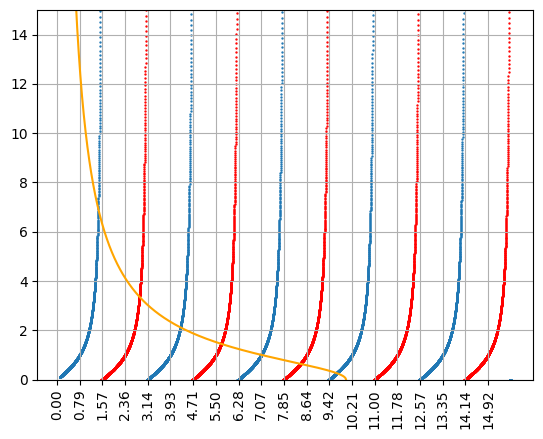

E1:  9.678884018488551
E2:  2.8523418944489465
E3:  4.271095337632868
E4:  5.679207796313675


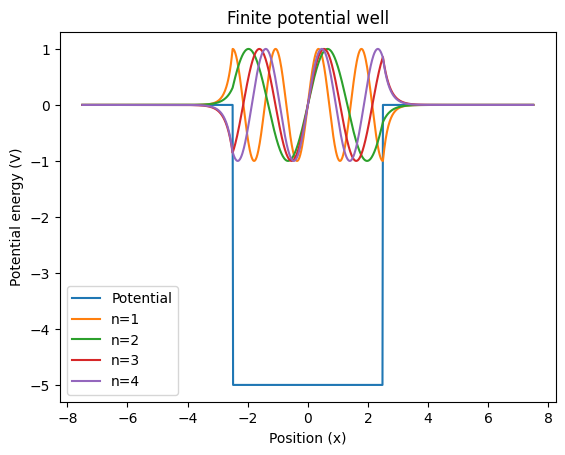

In [3]:
import numpy as np
import scipy as sp
import scipy.optimize
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Graphical / transcendental solution for the finite well
# ---------------------------------------------------------
z0square = 100

# define the transcendental equations
y1 = lambda z: np.tan(z)
y2 = lambda z: np.sqrt(z0square * z**(-2) - 1)
y3 = lambda z: np.tan(z + np.pi / 2)

# select a suitable range
upperlimit = 5 * np.pi
z = np.arange(0.1, upperlimit, .001)

# plot the equations
plt.scatter(z, y1(z), s=.5)
plt.plot(z, y2(z), c='orange')
plt.scatter(z, y3(z), s=.5, c='red')
plt.ylim((0, 15))
plt.xticks(np.arange(0, upperlimit, np.pi / 4), rotation=90)
plt.grid()
plt.show()

# write the transcendental equations as one
ftan = lambda z: y1(z) - y2(z)
fcot = lambda z: y3(z) - y2(z)

# NOTE: y2(z) is only real for z < sqrt(z0square) = 10.
# The original E1 bracket (9.42, 10.21) pokes past that limit,
# where y2 becomes NaN -> bisect fails. Pulling the right edge
# in to just under 10 fixes it.
E1 = sp.optimize.bisect(ftan, 9.42, 9.99)
E2 = sp.optimize.bisect(fcot, 2.36, 3.14)
E3 = sp.optimize.bisect(ftan, 3.9, 4.7)
E4 = sp.optimize.bisect(fcot, 5.5, 6.28)

print('E1: ', E1)
print('E2: ', E2)
print('E3: ', E3)
print('E4: ', E4)

# ---------------------------------------------------------
# Physical finite square well
# ---------------------------------------------------------
# Define constants
m = 1.0       # mass of particle
V0 = -5.0     # height of potential well
a = 5.0       # width of potential well
hbar = 1.0    # reduced Planck constant


# Define the potential function
def V(x):
    if abs(x) < a / 2:
        return V0
    else:
        return 0


# Define the wave function
def psi(x, E):
    k = np.sqrt(2 * m * (-V0 + E)) / hbar
    alpha = np.sqrt(2 * m * E) / hbar
    if abs(x) < a / 2:
        return np.sin(alpha * x)
    else:
        if x < 0:
            return np.exp(-k * (-x - a / 2)) * -np.sin(alpha * a / 2)
        else:
            return np.exp(-k * (x - a / 2)) * np.sin(alpha * a / 2)


# Define the x-axis
x = np.linspace(-a * 1.5, a * 1.5, 1000)

# Plot the potential function
plt.plot(x, [V(xi) for xi in x], label='Potential')
plt.xlabel("Position (x)")
plt.ylabel("Potential energy (V)")
plt.title("Finite potential well")

# Plot the wave function
plt.plot(x, [psi(xi, E1) for xi in x], label='n=1')
plt.plot(x, [psi(xi, E2) for xi in x], label='n=2')
plt.plot(x, [psi(xi, E3) for xi in x], label='n=3')
plt.plot(x, [psi(xi, E4) for xi in x], label='n=4')
plt.legend()
plt.show()